<a href="https://colab.research.google.com/github/sayalidudhane22/sentiment_analysis_vs_performance_analysis/blob/main/sentiment_vs_performance_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bitcoin Market Sentiment vs Hyperliquid Trader Performance

**Author:** Sayali Dudhane

**Goal:** Explore the relationship between Bitcoin Fear/Greed sentiment and trader performance (PnL, win rate, activity, position sizing) using historical Hyperliquid trade data, and derive insights that could inform a sentiment-aware trading strategy.

**Datasets**
1. historical_data.csv
2. fear_greed_index.csv

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

SENT_ORDER = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
SENT_COLORS = {"Extreme Fear": "#7f1d1d", "Fear": "#dc2626", "Neutral": "#a3a3a3",
               "Greed": "#16a34a", "Extreme Greed": "#14532d"}

## 1. Load & Clean Data

In [16]:
trades = pd.read_csv("/content/historical_data.csv")
fg = pd.read_csv("/content/fear_greed_index.csv")

trades["Timestamp IST"] = pd.to_datetime(trades["Timestamp IST"], format="%d-%m-%Y %H:%M")
trades["date"] = trades["Timestamp IST"].dt.date

fg["date"] = pd.to_datetime(fg["date"]).dt.date
fg["classification"] = pd.Categorical(fg["classification"], categories=SENT_ORDER, ordered=True)

print("Trade rows:", trades.shape)
print("Sentiment rows:", fg.shape)
print("Missing values in trades:\n", trades.isna().sum().sum())
trades.head()

Trade rows: (211224, 17)
Sentiment rows: (2644, 4)
Missing values in trades:
 0


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


In [17]:
# Merge trades with daily sentiment classification
df = trades.merge(fg[["date", "classification", "value"]], on="date", how="inner")
df = df.rename(columns={"value": "sentiment_score"})

# Closed PnL == 0 rows are position-building executions, not closed trades.
df["is_win"] = df["Closed PnL"] > 0
df["is_closed_trade"] = df["Closed PnL"] != 0

print(f"{df['date'].nunique()} unique trading days matched to sentiment")
df[["date", "classification", "sentiment_score", "Side", "Closed PnL"]].head()

479 unique trading days matched to sentiment


,date,classification,sentiment_score,Side,Closed PnL
0,2024-12-02,Extreme Greed,80,BUY,0.0
1,2024-12-02,Extreme Greed,80,BUY,0.0
2,2024-12-02,Extreme Greed,80,BUY,0.0
3,2024-12-02,Extreme Greed,80,BUY,0.0
4,2024-12-02,Extreme Greed,80,BUY,0.0


## 2. Performance by Sentiment Bucket

Aggregate closed-trade PnL, win rate, average trade size, and total volume for each of the five sentiment classes.

In [18]:
closed = df[df["is_closed_trade"]]

summary = closed.groupby("classification", observed=True).agg(
    trades=("Closed PnL", "count"),
    total_pnl=("Closed PnL", "sum"),
    avg_pnl=("Closed PnL", "mean"),
    median_pnl=("Closed PnL", "median"),
    win_rate=("is_win", "mean"),
    avg_size_usd=("Size USD", "mean"),
    total_volume_usd=("Size USD", "sum"),
).reindex(SENT_ORDER)
summary["win_rate"] = (summary["win_rate"] * 100).round(2)
summary

,trades,total_pnl,avg_pnl,median_pnl,win_rate,avg_size_usd,total_volume_usd
classification,,,,,,,
Extreme Fear,10406,7.391102e+05,71.027316,6.388050,76.22,5467.570419,5.689554e+07
Fear,29808,3.357155e+06,112.625988,6.350483,87.29,8041.140445,2.396903e+08
Neutral,18159,1.292921e+06,71.199993,4.583458,82.39,5556.444833,1.008995e+08
Greed,25176,2.150129e+06,85.403927,4.927600,76.89,5438.671764,1.369240e+08
Extreme Greed,20853,2.715171e+06,130.205309,8.530740,89.17,2779.563632,5.796224e+07


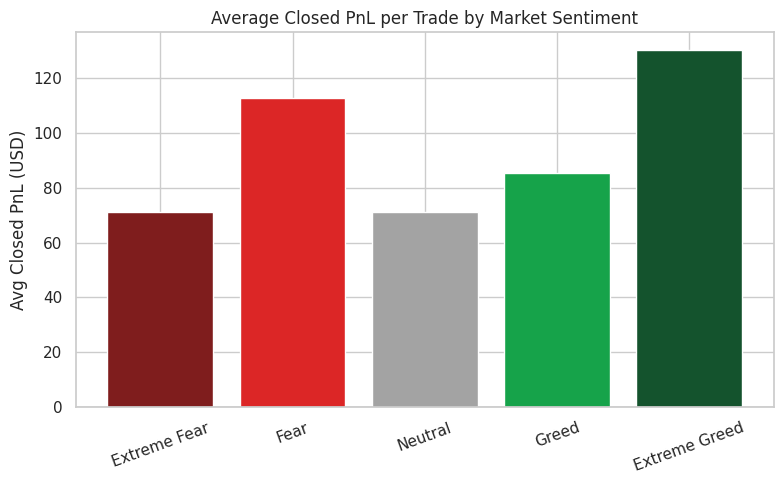

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = [SENT_COLORS[s] for s in summary.index]
ax.bar(summary.index, summary["avg_pnl"], color=colors)
ax.set_title("Average Closed PnL per Trade by Market Sentiment")
ax.set_ylabel("Avg Closed PnL (USD)")
ax.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

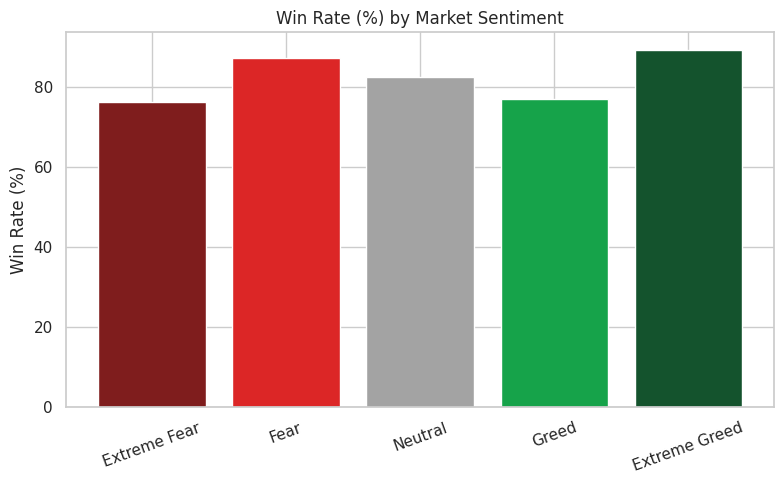

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(summary.index, summary["win_rate"], color=colors)
ax.set_title("Win Rate (%) by Market Sentiment")
ax.set_ylabel("Win Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

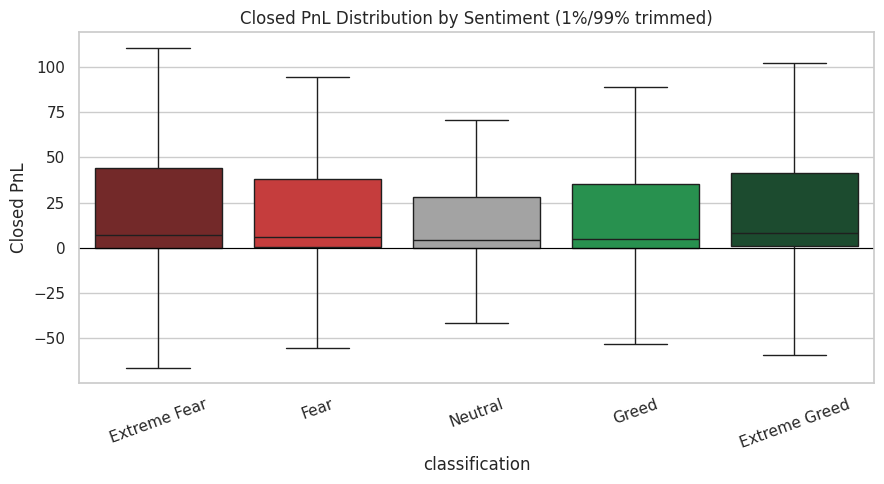

In [21]:
trimmed = closed[(closed["Closed PnL"] > closed["Closed PnL"].quantile(0.01)) &
                  (closed["Closed PnL"] < closed["Closed PnL"].quantile(0.99))]
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=trimmed, x="classification", y="Closed PnL", hue="classification",
            order=SENT_ORDER, palette=SENT_COLORS, ax=ax, showfliers=False, legend=False)
ax.set_title("Closed PnL Distribution by Sentiment (1%/99% trimmed)")
ax.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

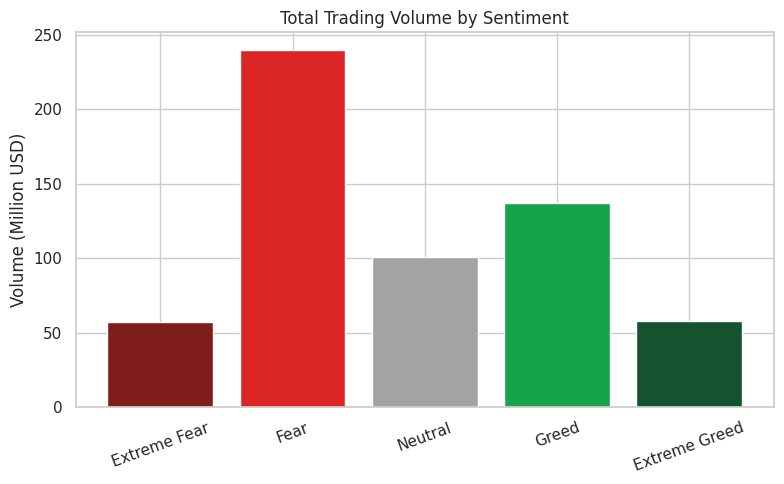

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(summary.index, summary["total_volume_usd"] / 1e6, color=colors)
ax.set_title("Total Trading Volume by Sentiment")
ax.set_ylabel("Volume (Million USD)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

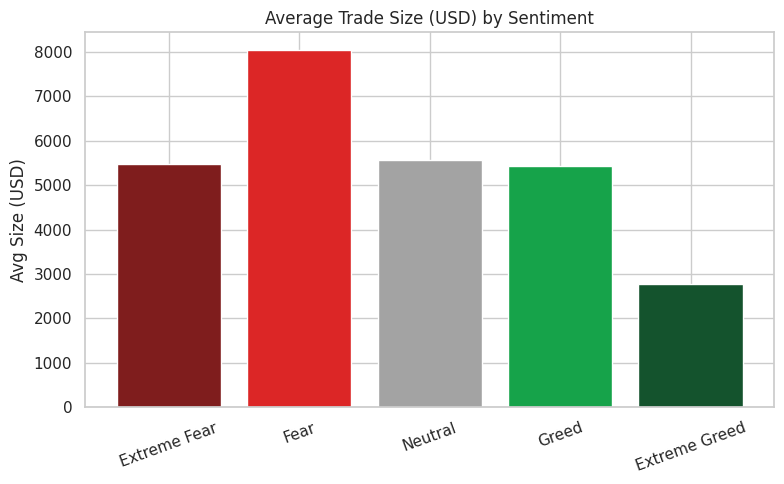

In [23]:
avg_size = closed.groupby("classification", observed=True)["Size USD"].mean().reindex(SENT_ORDER)
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(avg_size.index, avg_size.values, color=colors)
ax.set_title("Average Trade Size (USD) by Sentiment")
ax.set_ylabel("Avg Size (USD)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 3. Time Series View: Daily PnL vs Sentiment Score

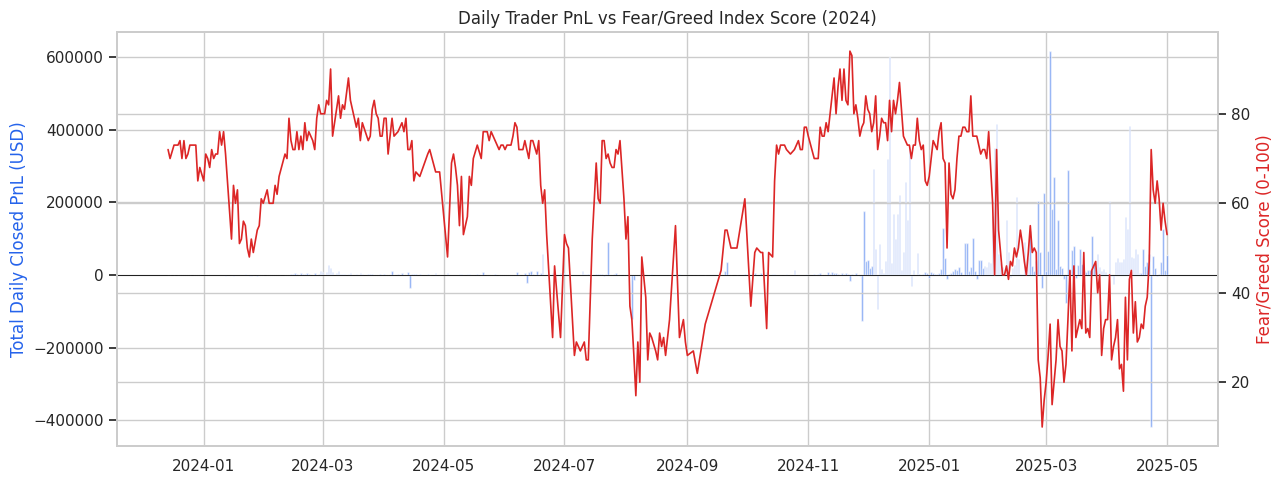

In [24]:
daily = closed.groupby(["date", "classification"], observed=True).agg(
    daily_pnl=("Closed PnL", "sum"),
    n_trades=("Closed PnL", "count"),
    win_rate=("is_win", "mean"),
).reset_index()

daily_total = daily.groupby("date")["daily_pnl"].sum().reset_index()
daily_total["date"] = pd.to_datetime(daily_total["date"])
fg2 = fg.copy()
fg2["date"] = pd.to_datetime(fg2["date"])
merged = daily_total.merge(fg2[["date", "value"]], on="date").sort_values("date")

fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.bar(merged["date"], merged["daily_pnl"], color="#2563eb", alpha=0.6)
ax1.set_ylabel("Total Daily Closed PnL (USD)", color="#2563eb")
ax1.axhline(0, color="black", linewidth=0.6)
ax2 = ax1.twinx()
ax2.plot(merged["date"], merged["value"], color="#dc2626", linewidth=1.2)
ax2.set_ylabel("Fear/Greed Score (0-100)", color="#dc2626")
ax1.set_title("Daily Trader PnL vs Fear/Greed Index Score (2024)")
plt.tight_layout()
plt.show()

## 4. Statistical Test: Is the Fear vs Greed PnL Difference Significant?

Welch's t-test comparing mean **daily total PnL** on Fear/Extreme-Fear days vs Greed/Extreme-Greed days.

In [25]:
fear_days = daily[daily["classification"].isin(["Fear", "Extreme Fear"])]["daily_pnl"]
greed_days = daily[daily["classification"].isin(["Greed", "Extreme Greed"])]["daily_pnl"]

t, p = stats.ttest_ind(fear_days, greed_days, equal_var=False)

print(f"Fear-day mean daily PnL:  ${fear_days.mean():,.2f}  (n={len(fear_days)} days)")
print(f"Greed-day mean daily PnL: ${greed_days.mean():,.2f}  (n={len(greed_days)} days)")
print(f"t-statistic: {t:.3f}")
print(f"p-value:     {p:.4f}")
print()
if p < 0.05:
    print("=> Statistically significant difference at alpha=0.05.")
else:
    print("=> Not statistically significant at alpha=0.05.")

Fear-day mean daily PnL:  $46,025.46  (n=89 days)
Greed-day mean daily PnL: $17,692.00  (n=275 days)
t-statistic: 2.404
p-value:     0.0178

=> Statistically significant difference at alpha=0.05.


## 5. Account-Level Behavior: Who Profits During Fear?

Segment cumulative PnL per account by sentiment regime to see whether Fear-day profitability is broad-based or concentrated in a few accounts (i.e. contrarian specialists vs all-weather traders).

In [26]:
acc = closed.groupby(["Account", "classification"], observed=True).agg(
    pnl=("Closed PnL", "sum"),
    trades=("Closed PnL", "count"),
).reset_index()

pivot = acc.pivot_table(index="Account", columns="classification", values="pnl",
                         aggfunc="sum", observed=True).fillna(0)

fear_cols = [c for c in ["Extreme Fear", "Fear"] if c in pivot.columns]
greed_cols = [c for c in ["Greed", "Extreme Greed"] if c in pivot.columns]
pivot["fear_pnl"] = pivot[fear_cols].sum(axis=1)
pivot["greed_pnl"] = pivot[greed_cols].sum(axis=1)

contrarians = pivot[pivot["fear_pnl"] > 0].sort_values("fear_pnl", ascending=False)
contrarians[["fear_pnl", "greed_pnl"]].head(10)

classification,fear_pnl,greed_pnl
Account,,
0x083384f897ee0f19899168e3b1bec365f52a9012,1.238143e+06,2.364369e+05
0xbaaaf6571ab7d571043ff1e313a9609a10637864,8.827904e+05,4.672458e+00
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,4.634781e+05,1.168888e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,3.434149e+05,2.165130e+04
0x513b8629fe877bb581bf244e326a047b249c4ff1,2.960444e+05,1.630477e+05
0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,2.745103e+05,3.631136e+04
0x8170715b3b381dffb7062c0298972d4727a0a63b,1.640062e+05,-3.792378e+05
0x420ab45e0bd8863569a5efbb9c05d91f40624641,1.091094e+05,1.610257e+04
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,1.027101e+05,1.639363e+06


## 6. Key Findings


**Fear days were significantly more profitable than Greed days**. Welch's t-test on mean daily total PnL: Fear/Extreme Fear days averaged $46,025/day (n=89 days) vs Greed/Extreme Greed days at $17,692/day (n=275 days). t = 2.404, p = 0.0178 — significant at α = 0.05. This runs counter to the assumption that panic causes losses.

**Extreme Greed has the best win rate (89.2%) but the smallest average trade size** ($2,780) — less than half the Fear-day average ($8,041). Traders take smaller, higher-conviction bets during euphoria rather than chasing size.

**Trading volume peaks during Fear ($239.7M), nearly double Extreme Greed ($57.9M)** — moderate fear, not panic or euphoria, is when this trader base is most active.

**Fear-day profit is concentrated in a handful of accounts**. The top account made $1.24M during Fear vs $236K during Greed; a couple of accounts (e.g. one with $882K Fear-PnL vs ~$5 Greed-PnL) look like genuinely contrarian, sentiment-timed strategies rather than traders who do well everywhere.

**Caveat: 32 accounts over ~16 months (2023–2025) is a small, likely non-random sample of active/professional traders**— treat p=0.0178 as a hypothesis worth validating on more data, not a settled edge.



**See `INSIGHTS.md` in the repo root for the full write-up.**